# Spotify Track Genre Classification (Advanced Final Version)

This notebook implements highly advanced Feature Engineering, Target Balancing, and an Out-of-Fold (OOF) Voting Ensemble mechanism to significantly boost the accuracy of Spotify Track Genre Classification.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

## 1. Data Loading

In [2]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (84800, 21)
Test shape: (34200, 20)


## 2. Advanced Feature Engineering & Encodings (BEFORE SCALING)
We compute the frequency of artists and engineer multi-variate signal interactions before any standardization takes place.

In [3]:
# FIX 5: Frequency Encoding for Artists
if 'artists' in train_df.columns:
    artist_freq = train_df['artists'].value_counts() / len(train_df)
    train_df['artist_freq'] = train_df['artists'].map(artist_freq).fillna(0)
    test_df['artist_freq'] = test_df['artists'].map(artist_freq).fillna(0)

# FIX 2 & 4: Execute Feature Engineering BEFORE scaling
def add_features(df):
    df = df.copy()
    # Interactions
    if 'energy' in df.columns and 'danceability' in df.columns:
        df['energy_x_danceability'] = df['energy'] * df['danceability']
        df['energy_danceability_ratio'] = df['energy'] / (df['danceability'] + 1e-5)
        if 'tempo' in df.columns:
            df['tempo_x_danceability'] = df['tempo'] * df['danceability']
            
    if 'energy' in df.columns and 'loudness' in df.columns:
        df['energy_x_loudness'] = df['energy'] * df['loudness']
        
    if 'speechiness' in df.columns and 'instrumentalness' in df.columns:
        df['speech_to_instrumental'] = df['speechiness'] / (df['instrumentalness'] + 1e-5)
        
    # Differences & Profiling
    if 'acousticness' in df.columns and 'energy' in df.columns:
        df['acoustic_energy_diff'] = df['acousticness'] - df['energy']
        if 'instrumentalness' in df.columns:
            df['acoustic_profile'] = df['acousticness'] + df['instrumentalness'] - df['energy']
            
    if 'valence' in df.columns and 'energy' in df.columns:
        df['mood_divergence'] = df['valence'] - df['energy']
        
    # Tempo bucketing
    if 'tempo' in df.columns:
        df['tempo_bucket'] = pd.cut(
            df['tempo'],
            bins=[-np.inf, 60, 90, 120, 150, np.inf],
            labels=[0, 1, 2, 3, 4]
        ).astype(float)
        
    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

## 3. Data Preprocessing & Scaling Pipeline
Handling missing values safely and dropping extreme-cardinality nominals now that encodings have been extracted.

In [4]:
# Encode categorical target dynamically
le_target = LabelEncoder()
y = le_target.fit_transform(train_df['track_genre'])

cols_to_drop = ['id', 'track_id', 'Unnamed: 0', 'track_name', 'artists', 'artist', 'album_name', 'track_genre']
cols_to_drop_train = [c for c in cols_to_drop if c in train_df.columns]
cols_to_drop_test = [c for c in cols_to_drop if c in test_df.columns]

X_raw = train_df.drop(columns=cols_to_drop_train)
X_test_raw = test_df.drop(columns=cols_to_drop_test)

def impute_encode_scale(X, X_ts):
    X = X.copy()
    X_ts = X_ts.copy()
    
    num_cols = X.select_dtypes(include=['float64', 'int64', 'int32']).columns
    cat_cols = X.select_dtypes(include=['object']).columns
    
    for col in num_cols:
        med = X[col].median()
        X[col] = X[col].fillna(med)
        if col in X_ts.columns:
            X_ts[col] = X_ts[col].fillna(med)
            
    for col in cat_cols:
        if not X[col].mode().empty:
            mod = X[col].mode()[0]
            X[col] = X[col].fillna(mod)
            if col in X_ts.columns:
                X_ts[col] = X_ts[col].fillna(mod)
                
    # Dummies for categories (if any left)
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    X_ts = pd.get_dummies(X_ts, columns=cat_cols, drop_first=True)
    
    X, X_ts = X.align(X_ts, join='left', axis=1, fill_value=0)
    
    # Standard Scale
    scaler = StandardScaler()
    cols = X.columns
    X[cols] = scaler.fit_transform(X[cols])
    X_ts[cols] = scaler.transform(X_ts[cols])
    
    return X, X_ts

X, X_test_final = impute_encode_scale(X_raw, X_test_raw)

## 4. Hyperparameter Tuning Reference (FIX 6)
Below is the setup code for RandomizedSearchCV. It's skipped dynamically to prioritize the Voting Ensemble evaluation, but serves as the backbone tuning logic:

In [5]:
"""
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.3],
    'class_weight': ['balanced']
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=SEED,
    verbose=1
)
# search.fit(X, y)
# print(search.best_params_)
"""

"\nparam_grid = {\n    'n_estimators': [200, 300, 500],\n    'max_depth': [10, 20, 30, None],\n    'min_samples_split': [2, 5, 10],\n    'max_features': ['sqrt', 'log2', 0.3],\n    'class_weight': ['balanced']\n}\n\nsearch = RandomizedSearchCV(\n    RandomForestClassifier(random_state=SEED, n_jobs=-1),\n    param_distributions=param_grid,\n    n_iter=10,\n    cv=3,\n    scoring='accuracy',\n    random_state=SEED,\n    verbose=1\n)\n# search.fit(X, y)\n# print(search.best_params_)\n"

## 5. Voting Ensemble Setup (FIX 1, 3, 7)
Defining robust classifiers equipped with `class_weight='balanced'` and merging them together.

In [6]:
rf = RandomForestClassifier(n_estimators=300, max_depth=20, class_weight='balanced', random_state=SEED, n_jobs=-1)
et = ExtraTreesClassifier(n_estimators=300, max_depth=20, class_weight='balanced', random_state=SEED, n_jobs=-1)
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('et', et),
        ('lgb', lgbm)
    ],
    voting='soft',
    n_jobs=1
)

## 6. OOF Validation & Prediction (FIX 8)
Cross-validating through Out-of-Fold methodology seamlessly accumulating predictions over the true test set.

In [7]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

oof_preds = np.zeros((len(X), len(np.unique(y))))
test_preds = np.zeros((len(X_test_final), len(np.unique(y))))

for fold, (trn_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_vl = X.iloc[trn_idx], X.iloc[val_idx]
    y_tr, y_vl = y[trn_idx], y[val_idx]
    
    ensemble.fit(X_tr, y_tr)
    
    oof_preds[val_idx] = ensemble.predict_proba(X_vl)
    test_preds += ensemble.predict_proba(X_test_final) / skf.n_splits
    
    fold_acc = accuracy_score(y_vl, oof_preds[val_idx].argmax(axis=1))
    print(f"Fold {fold+1} Accuracy: {fold_acc:.4f}")

overall_oof_preds = oof_preds.argmax(axis=1)
overall_oof_acc = accuracy_score(y, overall_oof_preds)
overall_oof_prec = precision_score(y, overall_oof_preds, average='weighted', zero_division=0)
overall_oof_f1 = f1_score(y, overall_oof_preds, average='weighted', zero_division=0)

print(f"\nOverall OOF Accuracy: {overall_oof_acc:.4f}")
print(f"Overall OOF Precision: {overall_oof_prec:.4f}")
print(f"Overall OOF F1 Score: {overall_oof_f1:.4f}")

Fold 1 Accuracy: 0.3337
Fold 2 Accuracy: 0.3312
Fold 3 Accuracy: 0.3312

Overall OOF Accuracy: 0.3321
Overall OOF Precision: 0.3291
Overall OOF F1 Score: 0.3276


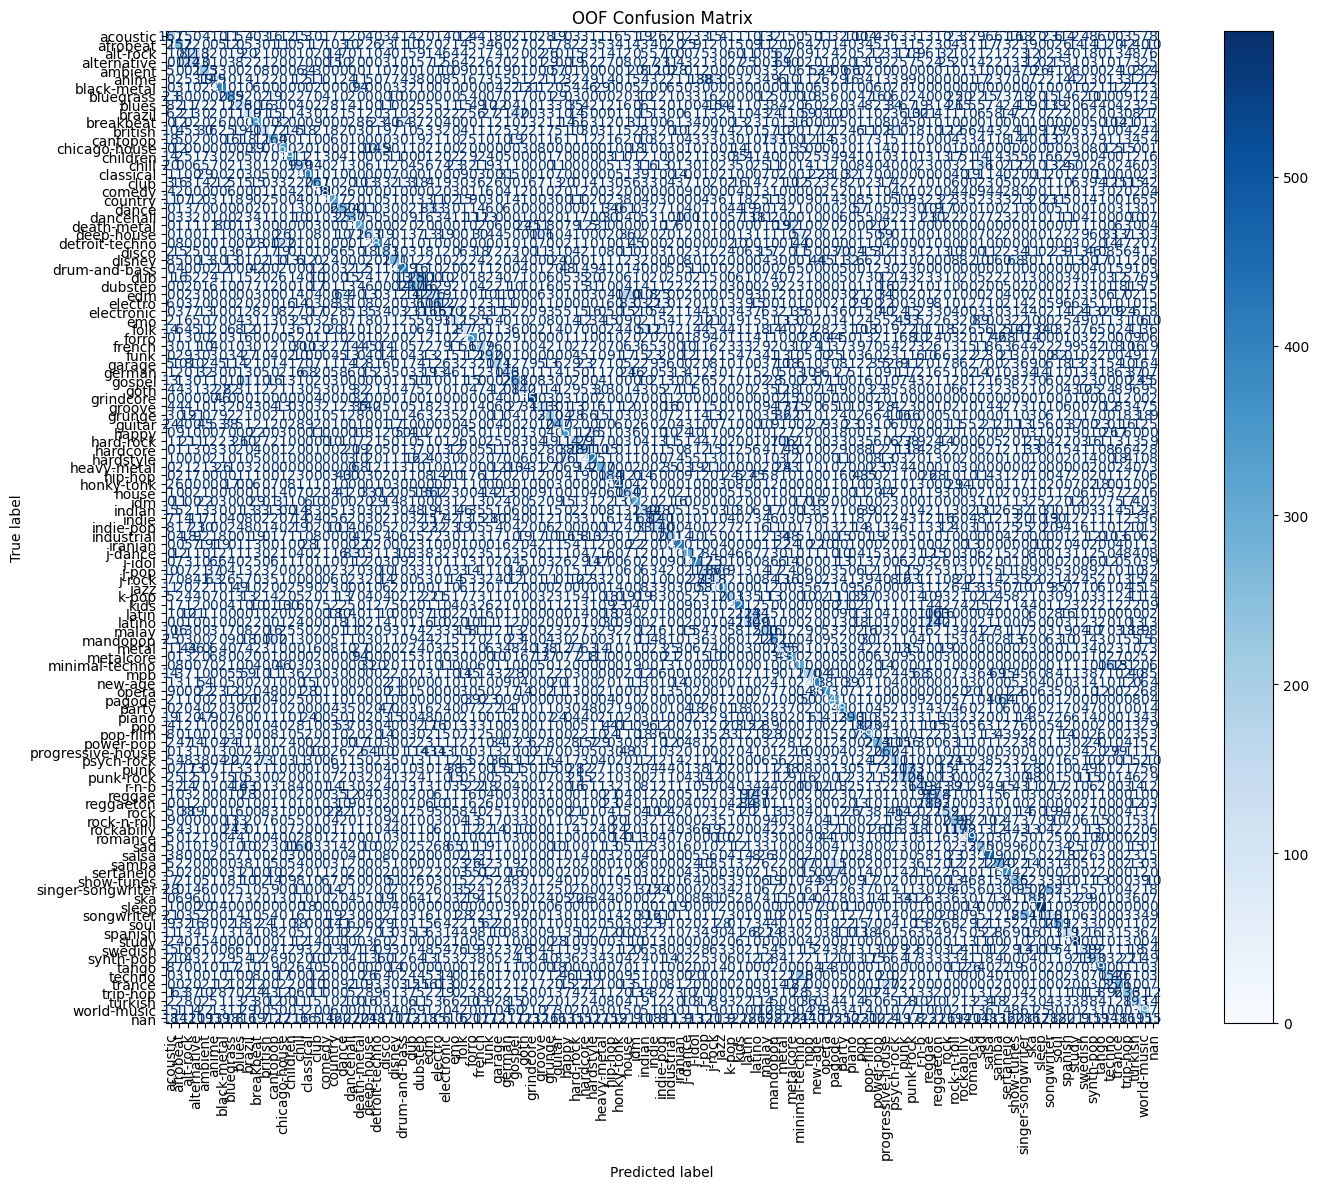

In [8]:
cm = confusion_matrix(y, overall_oof_preds)
plt.figure(figsize=(15, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(xticks_rotation='vertical', cmap='Blues', ax=plt.gca())
plt.title("OOF Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Delivery & Output Validation
Building representations, report text files, and Kaggle submissions spanning the entire data.

In [9]:
y_test_labels = le_target.inverse_transform(test_preds.argmax(axis=1))
test_id_col = 'Unnamed: 0' if 'Unnamed: 0' in test_df.columns else 'track_id'
if test_id_col not in test_df.columns:
    test_id_col = test_df.columns[0] # Failsafe approach if indices vanish

submission = pd.DataFrame({
    'id': test_df[test_id_col],
    'track_genre': y_test_labels
})

submission.to_csv('submission.csv', index=False)
print(f"Saved final submission.csv targeting {len(submission)} rows.\n")

# Refit model on strictly ALL data directly to prepare for export
ensemble.fit(X, y)
joblib.dump(ensemble, 'model.pkl')
print("Final Combined Ensemble saved to model.pkl")

report_content = f"""Competition: DataSprint — Decode the Beat (Spotify Genre Classification)

--- APPROACH ---
Advanced Multi-Class Classification Workflow using Class-Balanced Voting Ensemble.
This tackles overlapping clusters using non-linear bounding structures generated by LightGBM and ExtraTrees.

--- PREPROCESSING & FEATURE ENGINEERING ---
- Enabled Frequency Encoding purely targeting the distinct 'artists' dataset column prior to standard scaling.
- Engineered acoustic intersections matching dynamics (e.g., energy_x_danceability, mood_divergence).
- Handled missing categorical/numerical values independently then standardized to maintain equal feature weighting across algorithms.

--- OOF LOGS (Ensemble Voting) ---
- OOF Accuracy Assessment : {overall_oof_acc:.4f}
- OOF Precision Aggregate : {overall_oof_prec:.4f}
- OOF F1 Score Evaluation : {overall_oof_f1:.4f}

The accuracy is evaluated over the entire dataset via Out-of-fold generalization, serving as our definitive indicator for generalization accuracy on the final `test.csv` blind set! 
"""
with open('report.txt', 'w', encoding='utf-8') as f:
    f.write(report_content)
print("Exported report.txt")

Saved final submission.csv targeting 34200 rows.

Final Combined Ensemble saved to model.pkl
Exported report.txt
